# FakeFez Noise Model Analysis

This notebook provides a deep analysis of the FakeFez backend's noise model:

1. **Backend Properties**: T1, T2, gate errors, readout errors
2. **Noise Model Structure**: How noise is represented in Qiskit
3. **Quantum Error Channels**: Kraus operators and their physical meaning
4. **Pauli Error Extraction**: Converting noise to Pauli error rates (px, py, pz)
5. **Error Composition**: How errors accumulate along paths

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd

from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise.errors import QuantumError, ReadoutError
from qiskit.quantum_info import Kraus, SuperOp, Choi, PTM, Pauli, average_gate_fidelity

np.set_printoptions(precision=6, suppress=True)

## 1. Load FakeFez Backend

In [2]:
backend = FakeFez()
target = backend.target
coupling_map = backend.coupling_map

print(f"Backend: {backend.name}")
print(f"Number of qubits: {backend.num_qubits}")
print(f"Basis gates: {target.operation_names}")
print(f"Number of edges: {len(list(coupling_map.get_edges())) // 2}")

Backend: fake_fez
Number of qubits: 156
Basis gates: dict_keys(['switch_case', 'id', 'rz', 'for_loop', 'x', 'reset', 'sx', 'if_else', 'cz', 'delay', 'measure'])
Number of edges: 176


## 2. Extract Backend Properties

In [3]:
# Extract qubit properties
qubit_props = target.qubit_properties

qubit_data = {}
for i in range(backend.num_qubits):
    qubit_data[i] = {
        't1': qubit_props[i].t1,           # seconds
        't2': qubit_props[i].t2,           # seconds
        'frequency': qubit_props[i].frequency,  # Hz
    }

# Extract gate properties
gate_data = {}
for gate_name in ['sx', 'x', 'rz', 'cz', 'measure', 'reset']:
    if gate_name in target.operation_names:
        gate_props = target[gate_name]
        gate_data[gate_name] = {}
        for qubits, props in gate_props.items():
            if props is not None:
                gate_data[gate_name][qubits] = {
                    'error': props.error,
                    'duration': props.duration,  # seconds
                }

print("Sample qubit properties:")
for q in [0, 50, 100]:
    d = qubit_data[q]
    print(f"  Qubit {q}: T1={d['t1']*1e6:.2f}μs, T2={d['t2']*1e6:.2f}μs")

print(f"\nGate types available: {list(gate_data.keys())}")

Sample qubit properties:
  Qubit 0: T1=48.81μs, T2=42.38μs
  Qubit 50: T1=145.48μs, T2=130.89μs
  Qubit 100: T1=154.34μs, T2=29.24μs

Gate types available: ['sx', 'x', 'rz', 'cz', 'measure', 'reset']


In [4]:
# Gate error statistics
print("Gate Error Statistics:")
print("=" * 60)

for gate_name, gate_props in gate_data.items():
    errors = [p['error'] for p in gate_props.values() if p['error'] is not None]
    durations = [p['duration']*1e9 for p in gate_props.values() if p['duration'] is not None]  # ns
    
    if errors:
        print(f"\n{gate_name.upper()}:")
        print(f"  Error:    min={min(errors):.6f}, max={max(errors):.6f}, mean={np.mean(errors):.6f}")
    if durations:
        print(f"  Duration: min={min(durations):.1f}ns, max={max(durations):.1f}ns, mean={np.mean(durations):.1f}ns")

Gate Error Statistics:

SX:
  Error:    min=0.000100, max=0.002488, mean=0.000287
  Duration: min=24.0ns, max=24.0ns, mean=24.0ns

X:
  Error:    min=0.000100, max=0.002488, mean=0.000287
  Duration: min=24.0ns, max=24.0ns, mean=24.0ns

RZ:
  Error:    min=0.000000, max=0.000000, mean=0.000000
  Duration: min=0.0ns, max=0.0ns, mean=0.0ns

CZ:
  Error:    min=0.002139, max=1.000000, mean=0.045112
  Duration: min=84.0ns, max=104.0ns, mean=84.2ns

MEASURE:
  Error:    min=0.001465, max=0.105957, mean=0.013241
  Duration: min=1560.0ns, max=1560.0ns, mean=1560.0ns
  Duration: min=1584.0ns, max=1584.0ns, mean=1584.0ns


## 3. Build and Analyze Noise Model

In [5]:
# Build noise model from backend
noise_model = NoiseModel.from_backend(backend)

print("Noise Model Summary:")
print("=" * 60)
print(f"Basis gates: {noise_model.basis_gates}")
print(f"Noise instructions: {noise_model.noise_instructions}")
print(f"\nNoise model has:")
print(f"  - Default quantum errors: {len(noise_model._default_quantum_errors)}")
print(f"  - Local quantum errors: {len(noise_model._local_quantum_errors)}")
print(f"  - Default readout errors: {noise_model._default_readout_error}")
print(f"  - Local readout errors: {len(noise_model._local_readout_errors)}")

Noise Model Summary:
Basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
Noise instructions: ['cz', 'id', 'measure', 'reset', 'sx', 'x']

Noise model has:
  - Default quantum errors: 0
  - Local quantum errors: 5
  - Default readout errors: None
  - Local readout errors: 156


In [6]:
# Examine noise model structure
print("Local Quantum Errors by Gate:")
print("=" * 60)

error_counts = defaultdict(int)
for gate_qubits, errors in noise_model._local_quantum_errors.items():
    gate_name = gate_qubits  # This is actually just the gate name for local errors
    error_counts[gate_name] += 1

for gate, count in sorted(error_counts.items()):
    print(f"  {gate}: {count} qubit-specific errors")

Local Quantum Errors by Gate:
  cz: 1 qubit-specific errors
  id: 1 qubit-specific errors
  reset: 1 qubit-specific errors
  sx: 1 qubit-specific errors
  x: 1 qubit-specific errors


## 4. Analyze Quantum Error Channels

Quantum errors in Qiskit are represented using Kraus operators. For a channel $\mathcal{E}$:

$$\mathcal{E}(\rho) = \sum_k K_k \rho K_k^\dagger$$

where $\sum_k K_k^\dagger K_k = I$.

In [7]:
def get_quantum_error_for_gate(noise_model, gate_name, qubits):
    """
    Extract the QuantumError for a specific gate and qubit(s).
    
    Args:
        noise_model: NoiseModel object
        gate_name: str, e.g., 'sx', 'cz'
        qubits: tuple, e.g., (0,) for single-qubit, (0, 1) for two-qubit
    
    Returns:
        QuantumError or None
    """
    # Check local errors first
    if gate_name in noise_model._local_quantum_errors:
        local_errors = noise_model._local_quantum_errors[gate_name]
        if qubits in local_errors:
            return local_errors[qubits]
    
    # Fall back to default errors
    if gate_name in noise_model._default_quantum_errors:
        return noise_model._default_quantum_errors[gate_name]
    
    return None


# Test: Get error for sx gate on qubit 0
sx_error = get_quantum_error_for_gate(noise_model, 'sx', (0,))
if sx_error:
    print(f"SX gate error on qubit 0:")
    print(f"  Type: {type(sx_error)}")
    print(f"  Number of Kraus operators: {len(sx_error.to_quantumchannel().data)}")
else:
    print("No error found for sx on qubit 0")

SX gate error on qubit 0:
  Type: <class 'qiskit_aer.noise.errors.quantum_error.QuantumError'>
  Number of Kraus operators: 4


In [8]:
def analyze_quantum_error(quantum_error, name="Error"):
    """
    Analyze a QuantumError by examining its Kraus operators.
    """
    print(f"\n{'='*60}")
    print(f"Analysis of {name}")
    print(f"{'='*60}")
    
    # Convert to Kraus representation
    kraus = Kraus(quantum_error.to_quantumchannel())
    kraus_ops = kraus.data  # List of numpy arrays
    
    print(f"\nNumber of Kraus operators: {len(kraus_ops)}")
    print(f"Input/Output dimensions: {kraus.input_dims()} -> {kraus.output_dims()}")
    
    # Ensure we're working with numpy arrays
    kraus_arrays = [np.asarray(K) for K in kraus_ops]
    
    # Check completeness: sum(K†K) = I
    completeness = sum(K.conj().T @ K for K in kraus_arrays)
    print(f"\nCompleteness check (should be ~I):")
    print(completeness)
    
    # Show first few Kraus operators
    print(f"\nFirst few Kraus operators (up to 4):")
    for i, K in enumerate(kraus_arrays[:4]):
        K_matrix = np.asarray(K)
        if K_matrix.ndim >= 2:
            weight = np.trace(K_matrix.conj().T @ K_matrix).real
        else:
            weight = np.abs(K_matrix)**2 if K_matrix.size == 1 else 0
        print(f"\n  K[{i}] (weight={weight:.6f}):")
        print(f"  {K_matrix}")
    
    if len(kraus_arrays) > 4:
        print(f"\n  ... and {len(kraus_arrays) - 4} more operators")
    
    return kraus_arrays


# Analyze SX gate error
if sx_error:
    analyze_quantum_error(sx_error, "SX gate error on qubit 0")


Analysis of SX gate error on qubit 0

Number of Kraus operators: 4
Input/Output dimensions: (2,) -> (2,)

Completeness check (should be ~I):
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

First few Kraus operators (up to 4):

  K[0] (weight=1.997708):
  [[-0.99955 +0.j  0.      +0.j]
 [ 0.      +0.j -0.999304+0.j]]

  K[1] (weight=0.000814):
  [[ 0.018348-0.008372j  0.      +0.j      ]
 [ 0.      +0.j       -0.018352+0.008374j]]

  K[2] (weight=0.000985):
  [[0.      +0.j 0.031386+0.j]
 [0.      +0.j 0.      +0.j]]

  K[3] (weight=0.000493):
  [[ 0.      +0.j  0.      +0.j]
 [-0.022214+0.j  0.      +0.j]]


In [9]:
# Analyze CZ gate error (two-qubit)
# Find an edge that exists
edges = list(coupling_map.get_edges())
sample_edge = edges[0]

cz_error = get_quantum_error_for_gate(noise_model, 'cz', sample_edge)
if cz_error:
    # Use analyze_quantum_error for basic analysis
    kraus_ops = analyze_quantum_error(cz_error, f"CZ gate error on edge {sample_edge}")
else:
    print(f"No CZ error found for edge {sample_edge}")


Analysis of CZ gate error on edge (0, 1)

Number of Kraus operators: 16
Input/Output dimensions: (2, 2) -> (2, 2)

Completeness check (should be ~I):
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.-0.j  1.+0.j -0.+0.j  0.+0.j]
 [ 0.-0.j -0.-0.j  1.+0.j  0.-0.j]
 [ 0.-0.j  0.-0.j  0.+0.j  1.+0.j]]

First few Kraus operators (up to 4):

  K[0] (weight=3.949217):
  [[-0.994143+0.j  0.      -0.j  0.      -0.j  0.      +0.j]
 [-0.      +0.j -0.993284+0.j  0.      +0.j -0.      +0.j]
 [ 0.      -0.j  0.      +0.j -0.993979+0.j  0.      -0.j]
 [-0.      +0.j  0.      -0.j  0.      -0.j -0.993121+0.j]]

  K[1] (weight=0.005166):
  [[-0.035941+0.j -0.      +0.j -0.      +0.j  0.      +0.j]
 [ 0.      -0.j  0.035972-0.j  0.      +0.j  0.      -0.j]
 [-0.      +0.j  0.      +0.j -0.035904+0.j -0.      +0.j]
 [ 0.      -0.j -0.      +0.j -0.      +0.j  0.035935-0.j]]

  K[2] (weight=0.003177):
  [[ 0.028824-0.j -0.      +0.j -0.      +0.j  0.      +0.j]
 [-0.      +0.j  0.027519-0.j  0.      +0.j  0.   

## 5. Convert to Pauli Error Rates

For quantum network simulation, we often want to express noise as Pauli error rates.

A **Pauli channel** on a single qubit is:
$$\mathcal{E}(\rho) = p_I \rho + p_X X\rho X + p_Y Y\rho Y + p_Z Z\rho Z$$

where $p_I + p_X + p_Y + p_Z = 1$.

In [10]:
def quantum_error_to_pauli_rates(quantum_error):
    """
    Convert a single-qubit QuantumError to Pauli error rates.
    
    Uses the Pauli Transfer Matrix (PTM) representation.
    For a Pauli channel, the PTM is diagonal with entries:
    [1, 1-2(py+pz), 1-2(px+pz), 1-2(px+py)]
    
    Returns:
        dict with keys 'pi', 'px', 'py', 'pz'
    """
    # Convert to SuperOp then to PTM
    channel = quantum_error.to_quantumchannel()
    
    # For single qubit, we can use PTM
    if channel.num_qubits == 1:
        ptm = PTM(channel)
        ptm_matrix = ptm.data
        
        # PTM for Pauli channel:
        # [[1,     0,         0,         0       ],
        #  [0,  1-2(py+pz),   0,         0       ],
        #  [0,     0,      1-2(px+pz),   0       ],
        #  [0,     0,         0,      1-2(px+py)]]
        
        # Diagonal elements (for Pauli-diagonal channels)
        d1 = ptm_matrix[1, 1].real  # 1 - 2(py + pz)
        d2 = ptm_matrix[2, 2].real  # 1 - 2(px + pz)
        d3 = ptm_matrix[3, 3].real  # 1 - 2(px + py)
        
        # Solve for px, py, pz
        # py + pz = (1 - d1) / 2
        # px + pz = (1 - d2) / 2
        # px + py = (1 - d3) / 2
        
        # Adding all three: 2(px + py + pz) = (3 - d1 - d2 - d3) / 2
        # px + py + pz = (3 - d1 - d2 - d3) / 4
        
        total_error = (3 - d1 - d2 - d3) / 4
        
        # Subtract pairwise sums to get individual rates
        py_pz = (1 - d1) / 2
        px_pz = (1 - d2) / 2
        px_py = (1 - d3) / 2
        
        px = total_error - py_pz
        py = total_error - px_pz
        pz = total_error - px_py
        pi = 1 - total_error
        
        # Clamp to valid range (numerical errors)
        px = max(0, min(1, px))
        py = max(0, min(1, py))
        pz = max(0, min(1, pz))
        pi = max(0, min(1, pi))
        
        return {
            'pi': pi,
            'px': px,
            'py': py,
            'pz': pz,
            'total_error': px + py + pz,
            'ptm_diagonal': [1, d1, d2, d3]
        }
    else:
        return None  # Two-qubit case is more complex


# Test on SX error
if sx_error:
    pauli_rates = quantum_error_to_pauli_rates(sx_error)
    print("SX gate error on qubit 0 as Pauli rates:")
    print(f"  pI = {pauli_rates['pi']:.6f}")
    print(f"  pX = {pauli_rates['px']:.6f}")
    print(f"  pY = {pauli_rates['py']:.6f}")
    print(f"  pZ = {pauli_rates['pz']:.6f}")
    print(f"  Total error = {pauli_rates['total_error']:.6f}")
    print(f"  PTM diagonal = {pauli_rates['ptm_diagonal']}")

SX gate error on qubit 0 as Pauli rates:
  pI = 0.998854
  pX = 0.000370
  pY = 0.000370
  pZ = 0.000407
  Total error = 0.001146
  PTM diagonal = [1, np.float64(0.9984470432900502), np.float64(0.9984470432900502), np.float64(0.9985214997777154)]


In [11]:
# Extract Pauli error rates for all qubits (SX gate)
pauli_rates_by_qubit = {}

for q in range(backend.num_qubits):
    sx_err = get_quantum_error_for_gate(noise_model, 'sx', (q,))
    if sx_err:
        rates = quantum_error_to_pauli_rates(sx_err)
        if rates:
            pauli_rates_by_qubit[q] = rates

print(f"Extracted Pauli rates for {len(pauli_rates_by_qubit)} qubits")

# Statistics
px_values = [r['px'] for r in pauli_rates_by_qubit.values()]
py_values = [r['py'] for r in pauli_rates_by_qubit.values()]
pz_values = [r['pz'] for r in pauli_rates_by_qubit.values()]
total_values = [r['total_error'] for r in pauli_rates_by_qubit.values()]

print(f"\nSX Gate Pauli Error Statistics:")
print(f"  pX: min={min(px_values):.6f}, max={max(px_values):.6f}, mean={np.mean(px_values):.6f}")
print(f"  pY: min={min(py_values):.6f}, max={max(py_values):.6f}, mean={np.mean(py_values):.6f}")
print(f"  pZ: min={min(pz_values):.6f}, max={max(pz_values):.6f}, mean={np.mean(pz_values):.6f}")
print(f"  Total: min={min(total_values):.6f}, max={max(total_values):.6f}, mean={np.mean(total_values):.6f}")

Extracted Pauli rates for 156 qubits

SX Gate Pauli Error Statistics:
  pX: min=0.000027, max=0.001243, mean=0.000109
  pY: min=0.000027, max=0.001243, mean=0.000109
  pZ: min=0.000000, max=0.001911, mean=0.000255
  Total: min=0.000150, max=0.003732, mean=0.000474


## 6. Analyze Readout Errors

In [12]:
def analyze_readout_error(noise_model, qubit):
    """
    Analyze readout error for a specific qubit.
    
    Returns:
        dict with p(0|1) and p(1|0) probabilities
    """
    # Try tuple key first (most common format), then integer key
    qubit_key = (qubit,) if (qubit,) in noise_model._local_readout_errors else qubit
    
    if qubit_key in noise_model._local_readout_errors:
        ro_error = noise_model._local_readout_errors[qubit_key]
    elif noise_model._default_readout_error is not None:
        ro_error = noise_model._default_readout_error
    else:
        return None
    
    # Readout error is a 2x2 probability matrix:
    # [[P(0|0), P(1|0)],
    #  [P(0|1), P(1|1)]]
    probs = ro_error.probabilities
    
    return {
        'p0_given_0': probs[0][0],
        'p1_given_0': probs[0][1],  # Bit flip: 0 -> 1
        'p0_given_1': probs[1][0],  # Bit flip: 1 -> 0
        'p1_given_1': probs[1][1],
        'avg_error': (probs[0][1] + probs[1][0]) / 2
    }


# Debug: Check the key format used
print("Readout error key format:")
sample_keys = list(noise_model._local_readout_errors.keys())[:5]
print(f"  Sample keys: {sample_keys}")
print(f"  Key type: {type(sample_keys[0]) if sample_keys else 'N/A'}")

# Analyze readout errors for all qubits
readout_data = {}
for q in range(backend.num_qubits):
    ro = analyze_readout_error(noise_model, q)
    if ro:
        readout_data[q] = ro

print(f"\nReadout error data for {len(readout_data)} qubits")

# Sample
print("\nSample readout errors:")
for q in [0, 50, 100]:
    if q in readout_data:
        d = readout_data[q]
        print(f"  Qubit {q}: P(1|0)={d['p1_given_0']:.6f}, P(0|1)={d['p0_given_1']:.6f}, avg={d['avg_error']:.6f}")

Readout error key format:
  Sample keys: [(0,), (1,), (2,), (3,), (4,)]
  Key type: <class 'tuple'>

Readout error data for 156 qubits

Sample readout errors:
  Qubit 0: P(1|0)=0.011475, P(0|1)=0.011475, avg=0.011475
  Qubit 50: P(1|0)=0.003906, P(0|1)=0.003906, avg=0.003906
  Qubit 100: P(1|0)=0.007324, P(0|1)=0.007324, avg=0.007324


In [13]:
# Check for asymmetric readout errors
asymmetries = []
for q, ro in readout_data.items():
    asymmetry = abs(ro['p1_given_0'] - ro['p0_given_1'])
    asymmetries.append({
        'qubit': q,
        'p1_given_0': ro['p1_given_0'],
        'p0_given_1': ro['p0_given_1'],
        'asymmetry': asymmetry
    })

# Sort by asymmetry
asymmetries.sort(key=lambda x: x['asymmetry'], reverse=True)

print("Most asymmetric readout errors:")
print(f"{'Qubit':<8} {'P(1|0)':<12} {'P(0|1)':<12} {'Asymmetry':<12}")
print("-" * 44)
for a in asymmetries[:10]:
    print(f"{a['qubit']:<8} {a['p1_given_0']:<12.6f} {a['p0_given_1']:<12.6f} {a['asymmetry']:<12.6f}")

Most asymmetric readout errors:
Qubit    P(1|0)       P(0|1)       Asymmetry   
--------------------------------------------
0        0.011475     0.011475     0.000000    
1        0.011719     0.011719     0.000000    
2        0.004883     0.004883     0.000000    
3        0.015869     0.015869     0.000000    
4        0.001465     0.001465     0.000000    
5        0.007568     0.007568     0.000000    
6        0.006836     0.006836     0.000000    
7        0.020996     0.020996     0.000000    
8        0.004150     0.004150     0.000000    
9        0.007080     0.007080     0.000000    


## 7. Two-Qubit Gate Error Analysis (CZ)

In [14]:
def analyze_two_qubit_error(quantum_error, name="CZ Error"):
    """
    Analyze a two-qubit quantum error.
    
    For two qubits, the Pauli basis has 16 elements: II, IX, IY, IZ, XI, ..., ZZ
    """
    channel = quantum_error.to_quantumchannel()
    
    # Compute process fidelity using SuperOp
    superop = SuperOp(channel)
    
    # Convert to Kraus representation
    kraus = Kraus(channel)
    kraus_ops = [np.asarray(K) for K in kraus.data]
    
    print(f"\n{name}:")
    print(f"  Number of Kraus operators: {len(kraus_ops)}")
    print(f"  Dimensions: {channel.input_dims()} -> {channel.output_dims()}")
    
    # Compute weights of Kraus operators
    weights = []
    for K in kraus_ops:
        K_matrix = np.asarray(K)
        if K_matrix.ndim >= 2:
            weight = np.trace(K_matrix.conj().T @ K_matrix).real
        else:
            weight = np.abs(K_matrix)**2 if K_matrix.size == 1 else 0
        weights.append(weight)
    
    print(f"  Kraus weights: {weights[:5]}..." if len(weights) > 5 else f"  Kraus weights: {weights}")
    
    return {
        'num_kraus': len(kraus_ops),
        'weights': weights,
        'superop': superop
    }


# Analyze CZ errors for a few edges
sample_edges = list(coupling_map.get_edges())[:5]

cz_analysis = {}
for edge in sample_edges:
    cz_err = get_quantum_error_for_gate(noise_model, 'cz', edge)
    if cz_err:
        cz_analysis[edge] = analyze_two_qubit_error(cz_err, f"CZ on {edge}")


CZ on (0, 1):
  Number of Kraus operators: 16
  Dimensions: (2, 2) -> (2, 2)
  Kraus weights: [np.float64(3.949217405061389), np.float64(0.005166210590197255), np.float64(0.003176684763971004), np.float64(0.0029532753270634553), np.float64(0.006356195861781135)]...

CZ on (1, 0):
  Number of Kraus operators: 16
  Dimensions: (2, 2) -> (2, 2)
  Kraus weights: [np.float64(3.9492174050613906), np.float64(0.0051662105901971), np.float64(0.003176684763970849), np.float64(0.0029532753270633118), np.float64(0.006356195861781145)]...

CZ on (1, 2):
  Number of Kraus operators: 16
  Dimensions: (2, 2) -> (2, 2)
  Kraus weights: [np.float64(3.9811412381030244), np.float64(0.00243412594930348), np.float64(0.0012920512022812857), np.float64(0.0010669198451927254), np.float64(0.0017209645961379868)]...

CZ on (2, 1):
  Number of Kraus operators: 16
  Dimensions: (2, 2) -> (2, 2)
  Kraus weights: [np.float64(3.981141238103022), np.float64(0.0024341259493033587), np.float64(0.0012920512022811027), n

## 8. Thermal Relaxation Analysis

FakeFez includes thermal relaxation (T1 and T2) noise. This models:
- **Amplitude damping** (T1): Energy decay |1⟩ → |0⟩
- **Phase damping** (T2): Loss of phase coherence

In [15]:
def thermal_relaxation_pauli(t1, t2, gate_time):
    """
    Calculate Pauli error rates from thermal relaxation.
    
    For thermal relaxation with T1, T2, and gate time t:
    - Amplitude damping: p_amp = 1 - exp(-t/T1)
    - Phase damping: p_phase = 1 - exp(-t/T2) (after removing T1 contribution)
    
    The resulting Pauli rates (approximately) are:
    - pX ≈ pY ≈ p_amp / 4
    - pZ ≈ p_phase / 2
    """
    # Relaxation probabilities
    p_reset = 1 - np.exp(-gate_time / t1)  # Probability of decay
    p_phase = 1 - np.exp(-gate_time / t2)  # Probability of phase error
    
    # Pure dephasing rate (T2 contribution beyond T1)
    # 1/T2 = 1/(2*T1) + 1/T_phi
    # So T_phi = 1 / (1/T2 - 1/(2*T1))
    if t2 < 2 * t1:
        t_phi = 1 / (1/t2 - 1/(2*t1))
        p_dephasing = 1 - np.exp(-gate_time / t_phi)
    else:
        # T2 limited by T1 (T2 = 2*T1 limit)
        p_dephasing = 0
    
    return {
        't1': t1 * 1e6,  # μs
        't2': t2 * 1e6,  # μs
        'gate_time_ns': gate_time * 1e9,
        'p_reset': p_reset,
        'p_phase': p_phase,
        'p_dephasing': p_dephasing,
    }


# Analyze thermal relaxation for typical gate times
print("Thermal Relaxation Analysis:")
print("=" * 60)

# Get typical gate durations
sx_durations = [p['duration'] for p in gate_data['sx'].values() if p['duration']]
cz_durations = [p['duration'] for p in gate_data['cz'].values() if p['duration']]

avg_sx_time = np.mean(sx_durations)
avg_cz_time = np.mean(cz_durations)

print(f"\nAverage gate times:")
print(f"  SX: {avg_sx_time*1e9:.2f} ns")
print(f"  CZ: {avg_cz_time*1e9:.2f} ns")

# Sample qubits
print(f"\nThermal relaxation for sample qubits (during CZ gate):")
for q in [0, 50, 100]:
    t1 = qubit_data[q]['t1']
    t2 = qubit_data[q]['t2']
    thermal = thermal_relaxation_pauli(t1, t2, avg_cz_time)
    print(f"\n  Qubit {q} (T1={thermal['t1']:.1f}μs, T2={thermal['t2']:.1f}μs):")
    print(f"    p_reset (T1 decay):    {thermal['p_reset']:.6f}")
    print(f"    p_phase (total phase): {thermal['p_phase']:.6f}")
    print(f"    p_dephasing (pure):    {thermal['p_dephasing']:.6f}")

Thermal Relaxation Analysis:

Average gate times:
  SX: 24.00 ns
  CZ: 84.23 ns

Thermal relaxation for sample qubits (during CZ gate):

  Qubit 0 (T1=48.8μs, T2=42.4μs):
    p_reset (T1 decay):    0.001724
    p_phase (total phase): 0.001985
    p_dephasing (pure):    0.001124

  Qubit 50 (T1=145.5μs, T2=130.9μs):
    p_reset (T1 decay):    0.000579
    p_phase (total phase): 0.000643
    p_dephasing (pure):    0.000354

  Qubit 100 (T1=154.3μs, T2=29.2μs):
    p_reset (T1 decay):    0.000546
    p_phase (total phase): 0.002877
    p_dephasing (pure):    0.002605


## 9. Visualize Error Distributions

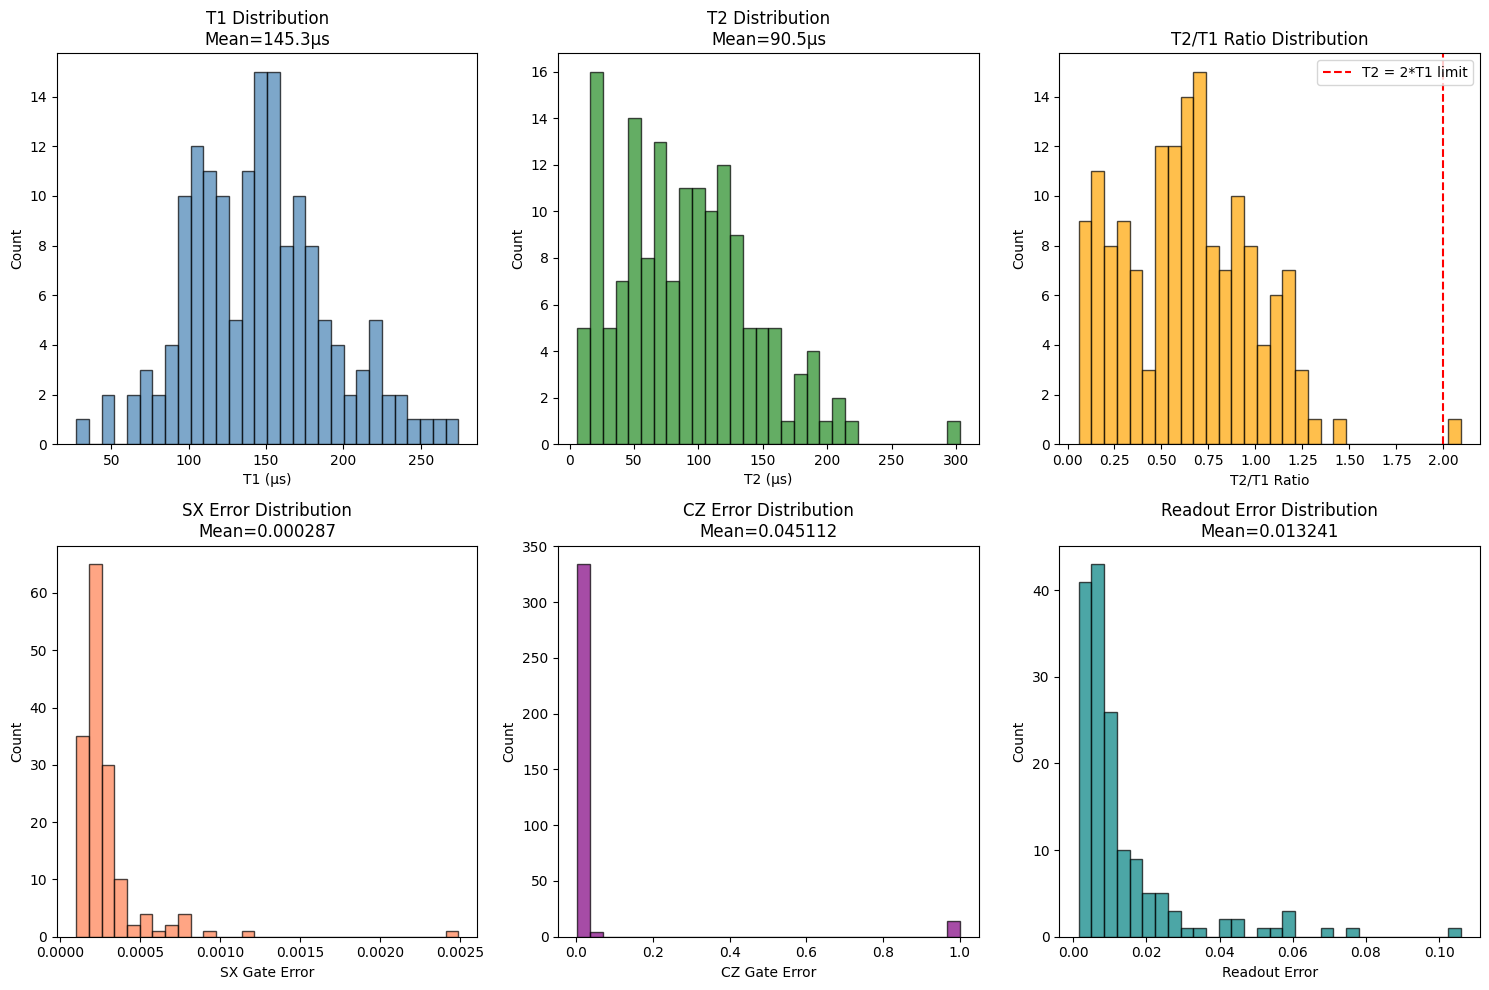

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# T1 distribution
t1_values = [qubit_data[q]['t1'] * 1e6 for q in qubit_data]
axes[0, 0].hist(t1_values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('T1 (μs)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title(f'T1 Distribution\nMean={np.mean(t1_values):.1f}μs')

# T2 distribution
t2_values = [qubit_data[q]['t2'] * 1e6 for q in qubit_data]
axes[0, 1].hist(t2_values, bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('T2 (μs)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title(f'T2 Distribution\nMean={np.mean(t2_values):.1f}μs')

# T2/T1 ratio (should be <= 2)
t2_t1_ratio = [qubit_data[q]['t2'] / qubit_data[q]['t1'] for q in qubit_data]
axes[0, 2].hist(t2_t1_ratio, bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(x=2, color='red', linestyle='--', label='T2 = 2*T1 limit')
axes[0, 2].set_xlabel('T2/T1 Ratio')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('T2/T1 Ratio Distribution')
axes[0, 2].legend()

# SX gate error distribution
sx_errors = [gate_data['sx'][(q,)]['error'] for q in range(backend.num_qubits) if (q,) in gate_data['sx']]
axes[1, 0].hist(sx_errors, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('SX Gate Error')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title(f'SX Error Distribution\nMean={np.mean(sx_errors):.6f}')

# CZ gate error distribution
cz_errors = [p['error'] for p in gate_data['cz'].values() if p['error'] is not None]
axes[1, 1].hist(cz_errors, bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('CZ Gate Error')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title(f'CZ Error Distribution\nMean={np.mean(cz_errors):.6f}')

# Readout error distribution
ro_errors = [gate_data['measure'][(q,)]['error'] for q in range(backend.num_qubits) if (q,) in gate_data['measure']]
axes[1, 2].hist(ro_errors, bins=30, color='teal', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Readout Error')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title(f'Readout Error Distribution\nMean={np.mean(ro_errors):.6f}')

plt.tight_layout()
plt.show()

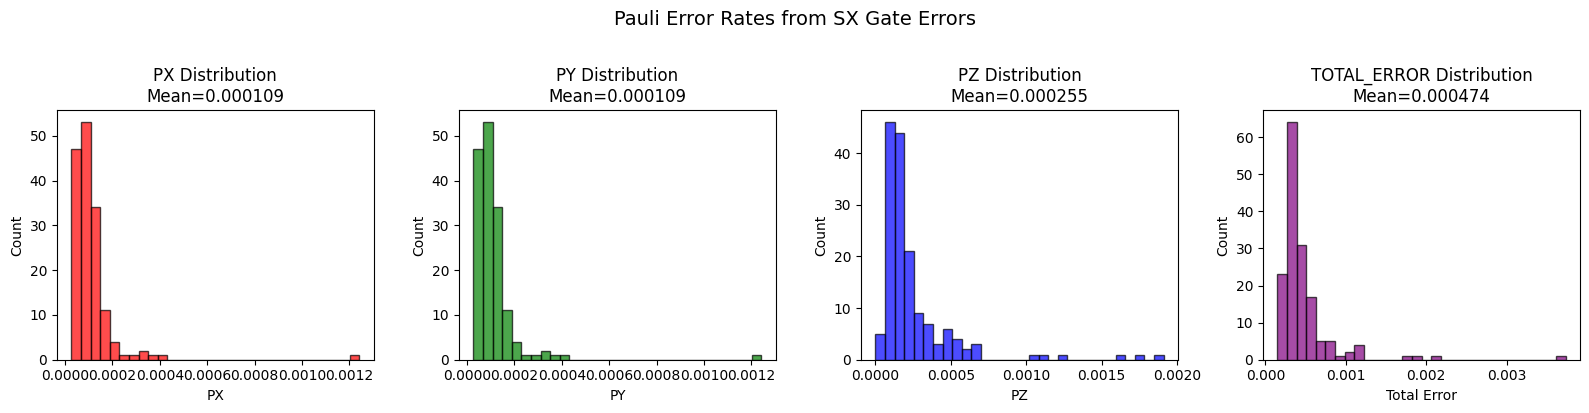

In [17]:
# Plot Pauli error rate distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (pauli, color) in enumerate([('px', 'red'), ('py', 'green'), ('pz', 'blue'), ('total_error', 'purple')]):
    values = [r[pauli] for r in pauli_rates_by_qubit.values()]
    axes[i].hist(values, bins=30, color=color, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(f'{pauli.upper()}' if pauli != 'total_error' else 'Total Error')
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{pauli.upper()} Distribution\nMean={np.mean(values):.6f}')

plt.suptitle('Pauli Error Rates from SX Gate Errors', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Summary Table

In [18]:
# Create summary DataFrame
summary_data = []

for q in range(backend.num_qubits):
    row = {
        'Qubit': q,
        'T1 (μs)': qubit_data[q]['t1'] * 1e6,
        'T2 (μs)': qubit_data[q]['t2'] * 1e6,
        'T2/T1': qubit_data[q]['t2'] / qubit_data[q]['t1'],
    }
    
    if (q,) in gate_data['sx']:
        row['SX Error'] = gate_data['sx'][(q,)]['error']
    
    if (q,) in gate_data['measure']:
        row['Readout Error'] = gate_data['measure'][(q,)]['error']
    
    if q in pauli_rates_by_qubit:
        row['pX'] = pauli_rates_by_qubit[q]['px']
        row['pY'] = pauli_rates_by_qubit[q]['py']
        row['pZ'] = pauli_rates_by_qubit[q]['pz']
    
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)

# Display with styling
styled = (df_summary.head(20)
    .style
    .format({
        'T1 (μs)': '{:.2f}',
        'T2 (μs)': '{:.2f}',
        'T2/T1': '{:.3f}',
        'SX Error': '{:.6f}',
        'Readout Error': '{:.6f}',
        'pX': '{:.6f}',
        'pY': '{:.6f}',
        'pZ': '{:.6f}',
    })
    .background_gradient(subset=['T1 (μs)', 'T2 (μs)'], cmap='Greens')
    .background_gradient(subset=['SX Error', 'Readout Error'], cmap='Reds')
    .set_caption('FakeFez Qubit Properties Summary (first 20 qubits)')
)

display(styled)

,Qubit,T1 (μs),T2 (μs),T2/T1,SX Error,Readout Error,pX,pY,pZ
0,0,48.81,42.38,0.868,0.000764,0.011475,0.000370,0.000370,0.000407
1,1,255.71,302.79,1.184,0.000178,0.011719,0.000092,0.000092,0.000084
2,2,274.39,99.98,0.364,0.000198,0.004883,0.000073,0.000073,0.000150
3,3,219.72,215.54,0.981,0.000239,0.015869,0.000119,0.000119,0.000120
4,4,190.90,161.93,0.848,0.000212,0.001465,0.000102,0.000102,0.000114
5,5,190.00,208.67,1.098,0.000278,0.007568,0.000141,0.000141,0.000135
6,6,213.90,129.32,0.605,0.000252,0.006836,0.000114,0.000114,0.000151
7,7,139.67,48.10,0.344,0.000299,0.020996,0.000095,0.000095,0.000259
8,8,74.72,43.30,0.580,0.000276,0.004150,0.000099,0.000099,0.000215
9,9,247.02,53.88,0.218,0.000238,0.007080,0.000061,0.000061,0.000235


In [19]:
# Final summary statistics
print("=" * 70)
print("FAKEFEZ NOISE MODEL SUMMARY")
print("=" * 70)

print(f"\nBackend: {backend.name}")
print(f"Qubits: {backend.num_qubits}")
print(f"Edges: {len(list(coupling_map.get_edges())) // 2}")

print(f"\n--- Coherence Times ---")
print(f"T1: {np.mean(t1_values):.1f} ± {np.std(t1_values):.1f} μs (range: {min(t1_values):.1f} - {max(t1_values):.1f})")
print(f"T2: {np.mean(t2_values):.1f} ± {np.std(t2_values):.1f} μs (range: {min(t2_values):.1f} - {max(t2_values):.1f})")

print(f"\n--- Gate Errors ---")
print(f"SX (1Q):     {np.mean(sx_errors):.6f} ± {np.std(sx_errors):.6f}")
print(f"CZ (2Q):     {np.mean(cz_errors):.6f} ± {np.std(cz_errors):.6f}")
print(f"Readout:     {np.mean(ro_errors):.6f} ± {np.std(ro_errors):.6f}")

print(f"\n--- Pauli Error Rates (from SX) ---")
print(f"pX: {np.mean(px_values):.6f} ± {np.std(px_values):.6f}")
print(f"pY: {np.mean(py_values):.6f} ± {np.std(py_values):.6f}")
print(f"pZ: {np.mean(pz_values):.6f} ± {np.std(pz_values):.6f}")

print(f"\n--- Gate Durations ---")
print(f"SX: {np.mean(sx_durations)*1e9:.2f} ns")
print(f"CZ: {np.mean(cz_durations)*1e9:.2f} ns")

FAKEFEZ NOISE MODEL SUMMARY

Backend: fake_fez
Qubits: 156
Edges: 176

--- Coherence Times ---
T1: 145.3 ± 45.0 μs (range: 27.1 - 274.4)
T2: 90.5 ± 52.7 μs (range: 6.0 - 302.8)

--- Gate Errors ---
SX (1Q):     0.000287 ± 0.000237
CZ (2Q):     0.045112 ± 0.194427
Readout:     0.013241 ± 0.015438

--- Pauli Error Rates (from SX) ---
pX: 0.000109 ± 0.000109
pY: 0.000109 ± 0.000109
pZ: 0.000255 ± 0.000282

--- Gate Durations ---
SX: 24.00 ns
CZ: 84.23 ns
